In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

# 0. Import Datasets:

In [2]:
customers_db = pd.read_csv("datasets/customer_db_with_outliers.csv", sep=",", index_col=0)
flights_db = pd.read_csv("datasets/flights_db_with_outliers.csv", sep=",", index_col=0)

# Dataset Merging with Temporal Information Preservation

### Merging Strategy
We begin by aligning customer and flight datasets using `Loyalty#` as the common key. To ensure consistency and avoid join issues, the key is explicitly cast to an integer type in both datasets. A **left join** is then applied so that all customers are retained in the merged dataset, even if they have no associated flight records.

At this stage, the datasets are successfully merged at the record level, preserving all customer attributes alongside their corresponding flight entries.

---

### Problem: Loss of Temporal Granularity in Standard Merges
A straightforward merge is not sufficient when the data contains **time-dependent information**. Each customer can have multiple flight records across different months, and simply aggregating after a merge risks losing:
- Month-wise flight activity
- Seasonal and usage patterns
- Information about when a customer was active or inactive

In particular, `Year` and `Month` exist at the flight level, and without special handling, this temporal structure cannot be preserved in a single customer-level table.

---

### Solution: Explicit Year–Month Construction and Controlled Aggregation
To address this, a `YearMonth` feature is explicitly created in `YYYY-MM` format. This acts as a stable temporal key that allows us to:
- Track customer activity at a monthly resolution
- Aggregate flight data without collapsing the time dimension prematurely

Using this key, multiple controlled aggregations are performed:
- **Customer-level aggregation** to preserve static attributes and summarize overall flight behavior
- **Month-wise indicators and counts** to capture whether a customer flew in a given month and how frequently
- **Activity window features** to identify first activity, last activity, total active months, and recency

---

### Action Taken
- Performed a left merge to retain all customer records
- Created a `YearMonth` temporal key to preserve monthly flight information
- Aggregated customer attributes and flight metrics in a structured manner
- Generated additional tables to explicitly retain month-wise usage patterns
- Merged all components into a final customer-level dataset that preserves both **behavioral totals** and **temporal dynamics**

This approach ensures that no critical time-based information is lost during merging, while still producing a clean, model-ready customer table.
# 1. Merge Customer and Flight Data

In [3]:
customers_db['Loyalty#'] = customers_db['Loyalty#'].astype(int)
flights_db['Loyalty#'] = flights_db['Loyalty#'].astype(int)
customer_flights_combined = pd.merge(customers_db, flights_db, on='Loyalty#', how='left')
customer_flights_combined.columns.values

array(['Loyalty#', 'Customer Name', 'Province or State', 'City',
       'Latitude', 'Longitude', 'Postal code', 'Gender', 'Education',
       'Location Code', 'Income', 'Marital Status', 'LoyaltyStatus',
       'EnrollmentDateOpening', 'Customer Lifetime Value',
       'EnrollmentType', 'IsCancelled', 'Tenure_months', 'Year', 'Month',
       'YearMonthDate', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed', 'avg_distance_per_flight',
       'companion_share'], dtype=object)

In [4]:
customer_flights_combined["YearMonth"] = (
    customer_flights_combined["Year"].astype(str)
    + "-"
    + customer_flights_combined["Month"].astype(str).str.zfill(2)
)

customer_agg = (
    customer_flights_combined
    .groupby("Loyalty#", as_index=False)
    .agg(
        customer_name=("Customer Name", "first"),
        province=("Province or State", "first"),
        city=("City", "first"),
        latitude=("Latitude", "first"),
        longitude=("Longitude", "first"),
        postal_code=("Postal code", "first"),
        gender=("Gender", "first"),
        education=("Education", "first"),
        location_code=("Location Code", "first"),
        income=("Income", "first"),
        marital_status=("Marital Status", "first"),
        loyalty_status=("LoyaltyStatus", "first"),
        enrollment_date=("EnrollmentDateOpening", "first"),
        enrollment_type=("EnrollmentType", "first"),
        customer_lifetime_value=("Customer Lifetime Value", "first"),
        is_cancelled=("IsCancelled", "max"),
        tenure_months=("Tenure_months", "max"),
        NumFlights=("NumFlights", "sum"),
        NumFlightsWithCompanions=("NumFlightsWithCompanions", "sum"),
        DistanceKM=("DistanceKM", "sum"),
        PointsAccumulated=("PointsAccumulated", "sum"),
        PointsRedeemed=("PointsRedeemed", "sum"),
        DollarCostPointsRedeemed=("DollarCostPointsRedeemed", "sum"),
    )
)

flights_count_ym = (
    customer_flights_combined
    .groupby(["Loyalty#", "YearMonth"])["NumFlights"]
    .sum()
    .unstack(fill_value=0)
    .add_prefix("flights_taken_")
    .reset_index()
)

usage_window = (
    customer_flights_combined
    .groupby("Loyalty#", as_index=False)
    .agg(
        last_active_month=("YearMonth", "max"),
    )
)

final_customer_table = (
    customer_agg
    .merge(usage_window, on="Loyalty#", how="left")
    .merge(flights_count_ym, on="Loyalty#", how="left")
)

customer_flights_combined = final_customer_table

## 1.1 Data Consistency and empty rows check

In [5]:
customer_flights_combined.columns.values

array(['Loyalty#', 'customer_name', 'province', 'city', 'latitude',
       'longitude', 'postal_code', 'gender', 'education', 'location_code',
       'income', 'marital_status', 'loyalty_status', 'enrollment_date',
       'enrollment_type', 'customer_lifetime_value', 'is_cancelled',
       'tenure_months', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed', 'last_active_month',
       'flights_taken_2019-01', 'flights_taken_2019-02',
       'flights_taken_2019-03', 'flights_taken_2019-04',
       'flights_taken_2019-05', 'flights_taken_2019-06',
       'flights_taken_2019-07', 'flights_taken_2019-08',
       'flights_taken_2019-09', 'flights_taken_2019-10',
       'flights_taken_2019-11', 'flights_taken_2019-12',
       'flights_taken_2020-01', 'flights_taken_2020-02',
       'flights_taken_2020-03', 'flights_taken_2020-04',
       'flights_taken_2020-05', 'flights_taken_2020-06',
       'flights_taken

In [6]:
customer_flights_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16375 entries, 0 to 16374
Data columns (total 61 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Loyalty#                  16375 non-null  int64  
 1   customer_name             16375 non-null  object 
 2   province                  16375 non-null  object 
 3   city                      16375 non-null  object 
 4   latitude                  16375 non-null  float64
 5   longitude                 16375 non-null  float64
 6   postal_code               16375 non-null  object 
 7   gender                    16375 non-null  object 
 8   education                 16375 non-null  object 
 9   location_code             16375 non-null  object 
 10  income                    16375 non-null  float64
 11  marital_status            16375 non-null  object 
 12  loyalty_status            16375 non-null  object 
 13  enrollment_date           16375 non-null  object 
 14  enroll

In [7]:
customer_flights_combined.isna().sum()[
    customer_flights_combined.isna().sum() > 0
].sort_values(ascending=False)



Series([], dtype: int64)

# 2 Feature Engineering

## 2.1 Feature Engineering

In [8]:
fe_df = customer_flights_combined.copy()

## 2.1.1 Temporal Feature Engineering

Temporal feature engineering focuses on extracting meaningful patterns from time-based flight activity that has already been expanded into **month-level indicators and counts**. Instead of relying on raw year and month columns, this approach leverages derived monthly features to preserve temporal behavior while remaining compatible with a customer-level dataset.

---

### 1. is_peak_season_proxy

**Description**  
`is_peak_season_proxy` is a binary feature that indicates whether a customer has taken **at least one flight during peak summer months (June, July, or August)**. A value of 1 represents any flight activity in these months, while 0 indicates no summer travel.

**Why this feature is created**  
Direct indicators for travel purpose, holidays, or vacation periods are not available in the dataset. However, summer months are strongly associated with leisure and vacation travel. Since flight activity has already been transformed into month-specific features (`flight_taken_YYYY-MM`), this proxy allows us to detect peak-season behavior without reintroducing raw temporal columns.

**How it will be used**  
This feature helps differentiate customers who travel during peak vacation periods from those who do not. It introduces seasonal behavioral context into downstream analysis and can support clustering or segmentation by separating leisure-oriented travelers from more routine or off-season travelers.

---

### 2. season_flight_count (Winter, Spring, Summer, Fall)

**Description**  
Seasonal flight count features represent the **total number of flights taken by a customer in each season**:
- `winter_flight_count`
- `spring_flight_count`
- `summer_flight_count`
- `fall_flight_count`

Each feature is computed by summing month-wise flight counts (`flights_taken_YYYY-MM`) that fall within the corresponding season.

**Why this feature is created**  
Month-level features provide fine-grained detail but can become high-dimensional and harder to interpret. Aggregating them into seasonal counts reduces dimensionality while still preserving meaningful temporal structure. This allows us to capture broader travel patterns without losing behavioral signal.

**How it will be used**  
These features quantify how a customer’s travel is distributed across seasons. They can be used directly in clustering models or exploratory analysis to identify customers with strong seasonal preferences, such as summer-heavy or winter-heavy travelers.

---

### 3. season (Dominant Travel Season)

**Description**  
The `season` feature identifies the **dominant travel season** for each customer. It is derived by selecting the season with the highest flight count among winter, spring, summer, and fall.

**Why this feature is created**  
While seasonal counts capture volume, a single dominant season provides a concise and interpretable summary of a customer’s primary travel pattern. This reduces complexity and highlights behavioral tendencies in a categorical form.

**How it will be used**  
After encoding, this feature can be used in clustering and segmentation to group customers based on their predominant travel season. It also improves interpretability by making seasonal preferences explicit in the final customer profile.

---

### Summary

The temporal features in this section are derived entirely from **month-wise flight indicators and counts**, ensuring that temporal information is preserved even after aggregation. Together, these features capture peak-season behavior, seasonal intensity, and dominant travel periods, enabling richer behavioral insights and more meaningful customer segmentation based on *when* customers travel.


In [9]:
summer_cols = [
    c for c in fe_df.columns
    if c.startswith("flight_taken_")
    and c.endswith(("-06", "-07", "-08"))
]

fe_df["is_peak_season_proxy"] = (fe_df[summer_cols].sum(axis=1) > 0).astype(int)


season_months = {
    "winter": ("-12", "-01", "-02"),
    "spring": ("-03", "-04", "-05"),
    "summer": ("-06", "-07", "-08"),
    "fall":   ("-09", "-10", "-11"),
}

for season, suffixes in season_months.items():
    cols = [
        c for c in fe_df.columns
        if c.startswith("flights_taken_") and c.endswith(suffixes)
    ]
    fe_df[f"{season}_flight_count"] = fe_df[cols].sum(axis=1)

fe_df["season"] = (
    fe_df[["winter_flight_count", "spring_flight_count",
           "summer_flight_count", "fall_flight_count"]]
    .idxmax(axis=1)
    .str.replace("_flight_count", "")
)


## 2.2.2 Behavioral Feature Engineering

Behavioral feature engineering focuses on capturing **how customers travel**, not just how much they travel. These features normalize raw activity counts and introduce ratios that reflect travel intensity, engagement, and usage patterns. This normalization is especially important for clustering, as customers with similar totals may exhibit very different behaviors once tenure and usage style are taken into account.

---

### 1. flights_per_month

**Description**  
`flights_per_month` measures the average number of flights taken by a customer per active month. It reflects how frequently a customer travels over their observed activity span.

**Why this feature is created**  
Total flight counts are strongly influenced by how long a customer has been active. By normalizing the number of flights by `activity_span_months`, we enable fair comparison between customers with short and long tenures, while safely handling edge cases where the activity span may be zero.

**How it will be used**  
This feature will be used directly in clustering to distinguish frequent travelers from occasional ones. It helps identify high-engagement customers and separates consistent travel behavior from sporadic usage.

---

### 2. points_per_flight

**Description**  
`points_per_flight` represents the average number of loyalty points accumulated per flight by a customer.

**Why this feature is created**  
Raw points accumulated are largely driven by the number of flights taken. Normalizing points by flight count reveals differences in travel value per trip, which may be influenced by distance, fare type, or cabin class. Division-by-zero cases are explicitly handled to maintain numerical stability.

**How it will be used**  
This feature helps differentiate customers who earn higher value per flight from those who primarily take shorter or lower-value trips. It supports the identification of premium or long-haul traveler segments.

---

### 3. redeem_ratio

**Description**  
`redeem_ratio` measures the proportion of accumulated loyalty points that a customer has redeemed.

**Why this feature is created**  
Earning points and redeeming points represent distinct behavioral patterns. This ratio captures how actively a customer engages with the loyalty program beyond accumulation, while safely handling customers with zero accumulated points.

**How it will be used**  
This feature helps distinguish reward-focused customers from long-term accumulators who rarely redeem. It adds an engagement dimension to clustering and behavioral segmentation.

---

### 4. avg_distance_per_flight

**Description**  
`avg_distance_per_flight` captures the average distance traveled per flight by a customer.

**Why this feature is created**  
Total distance alone does not reflect trip characteristics. Normalizing distance by flight count reveals whether a customer typically takes short-haul or long-haul trips. Zero-flight cases are handled explicitly to avoid invalid values.

**How it will be used**  
This feature supports differentiation between regional travelers and long-distance travelers and contributes to identifying customer segments based on travel style.

---

### 5. companion_share

**Description**  
`companion_share` represents the proportion of flights taken with companions relative to total flights.

**Why this feature is created**  
Traveling alone versus with companions reflects different behavioral and possibly purpose-driven patterns (e.g., business vs. leisure travel). This ratio captures that behavioral signal while remaining independent of total flight volume.

**How it will be used**  
This feature helps separate solo travelers from group or family travelers and enhances behavioral clustering by incorporating travel context.

---

### Summary

The behavioral features in this section transform raw counts into normalized, interpretable metrics that capture **travel frequency, value per trip, loyalty engagement, travel distance, and companionship behavior**. Together, these features provide a more nuanced and comparable representation of customer behavior, significantly improving clustering quality and interpretability.


In [10]:
fe_df['flights_per_month'] = fe_df['NumFlights'] / fe_df['tenure_months'].replace(0, 1)

fe_df['points_per_flight'] = fe_df['PointsAccumulated'] / fe_df['NumFlights'].replace(0, 1)

fe_df['redeem_ratio'] = fe_df['PointsRedeemed'] / fe_df['PointsAccumulated'].replace(0, 1)

fe_df["avg_distance_per_flight"] = np.where(
    fe_df["NumFlights"] > 0,
    fe_df["DistanceKM"] / fe_df["NumFlights"],
    0
)

fe_df["companion_share"] = np.where(
    fe_df["NumFlights"] > 0,
    fe_df["NumFlightsWithCompanions"] / fe_df["NumFlights"],
    0
)


## 2.2.3 Geographic Feature Engineering

Geographic feature engineering focuses on incorporating spatial information into the dataset to capture location-based travel patterns. Geographic features are especially important when the final objective includes geo-based clustering, as they allow the model to identify spatial similarities and regional travel behaviors among customers.

---

### 1. geo_point

**Description**  
geo_point is a composite geographic feature that represents a customer’s location as a pair of latitude and longitude coordinates. Together, these coordinates define a precise point on the Earth’s surface.

**Why this feature is created**  
Latitude and longitude stored separately are not directly suitable for spatial analysis or distance-based clustering. Combining them into a single geographic point preserves spatial relationships and enables the use of geographic distance metrics.

**How it will be used**  
This feature will be used as the foundation for geographic clustering and spatial analysis. It enables the identification of region-based customer segments, supports distance-based clustering methods, and allows analysis of geographic travel concentration. It is particularly useful for detecting clusters of customers with similar geographic origins or travel patterns.

---

### Summary

The geographic feature introduced in this section provides spatial context that complements temporal and behavioral features. By incorporating location information, the clustering process can capture regional similarities and produce more meaningful, geographically informed customer segments.


In [11]:
fe_df['geo_point'] = list(zip(fe_df['latitude'], fe_df['longitude']))

fe_df.drop(columns=['latitude', 'longitude'], inplace=True)

## 2.2.4 Data Inconsistency check for new features

In [12]:
fe_df.isna().sum()[
    fe_df.isna().sum() > 0
].sort_values(ascending=False)

Series([], dtype: int64)

In [13]:
fe_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16375 entries, 0 to 16374
Data columns (total 71 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Loyalty#                  16375 non-null  int64  
 1   customer_name             16375 non-null  object 
 2   province                  16375 non-null  object 
 3   city                      16375 non-null  object 
 4   postal_code               16375 non-null  object 
 5   gender                    16375 non-null  object 
 6   education                 16375 non-null  object 
 7   location_code             16375 non-null  object 
 8   income                    16375 non-null  float64
 9   marital_status            16375 non-null  object 
 10  loyalty_status            16375 non-null  object 
 11  enrollment_date           16375 non-null  object 
 12  enrollment_type           16375 non-null  object 
 13  customer_lifetime_value   16375 non-null  float64
 14  is_can

## 3. Discretization and Binning of Customer-Level Features

This section focuses on discretizing (binning) numerical features **after customer-level aggregation has already been completed**. No merging or aggregation is performed here. All operations assume that the input dataframe (`fe_df`) already contains **one row per customer**, with flight-level information previously summarized.

Discretization is applied to improve interpretability, reduce the influence of skewed distributions, and create stable categorical representations suitable for clustering and behavioral analysis.

---

### Distribution Analysis Using Histograms and Skewness

**Why distribution analysis was performed**  
For all selected numerical features, histograms were plotted along with mean and median indicators. Skewness values were explicitly computed and displayed for each feature.

Many customer-level metrics showed strong right skew, indicating that a small subset of customers had disproportionately high values.

**How this informed discretization**  
Using raw numerical values in such cases could distort distance-based clustering and reduce interpretability. Discretization was therefore applied to convert continuous variables into behaviorally meaningful ranges while limiting the influence of extreme values.

---

### Binned Feature Definitions and Thresholds

#### clv_band (Customer Lifetime Value)

Customer lifetime value was discretized into:
- **low_value**: up to 5,000  
- **mid_value**: 5,001 to 15,000  
- **high_value**: 15,001 to 30,000  
- **very_high_value**: above 30,000  

This separates low-impact customers from high-value and premium customers while controlling for extreme CLV values.

---

#### points_redeemed_band

Points redemption behavior was binned as:
- **none**: 0 points redeemed  
- **low**: up to 1,000 points  
- **medium**: 1,001 to 5,000 points  
- **high**: above 5,000 points  

These bands reflect increasing levels of engagement with the loyalty rewards system.

---

#### num_flights_band

Flight frequency was categorized into:
- **no_travel**: 0 flights  
- **occasional**: 1 to 3 flights  
- **regular**: 4 to 8 flights  
- **frequent**: more than 8 flights  

This distinguishes inactive customers from consistently active travelers.

---

#### companion_flights_band

Companion travel behavior was grouped as:
- **solo_only**: no companion flights  
- **occasional_companion**: 1 to 2 companion flights  
- **family_traveler**: 3 to 6 companion flights  
- **group_traveler**: more than 6 companion flights  

These categories capture differences between solo, family, and group travel patterns.

---

#### avg_distance_per_flight_band

Average distance per flight was first computed and then discretized into:
- **no_flights**: no recorded flights  
- **short_haul_traveler**: up to 1,500 km  
- **medium_haul_traveler**: 1,501 to 3,500 km  
- **long_haul_traveler**: above 3,500 km  

This separates regional travelers from long-haul flyers.

---

#### redeem_ratio_band

Reward usage intensity was captured using redemption ratios:
- **no_points**: no accumulated points  
- **rare_redeemer**: up to 10% redeemed  
- **light_redeemer**: 10% to 40% redeemed  
- **active_redeemer**: 40% to 80% redeemed  
- **heavy_redeemer**: above 80% redeemed  

This feature highlights how actively customers convert earned points into rewards.

---

#### tenure_band

Customer tenure was discretized into lifecycle stages:
- **new_customer**: up to 12 months  
- **established**: 13 to 36 months  
- **loyal**: 37 to 72 months  
- **veteran**: more than 72 months  

These stages represent progression in customer maturity and loyalty.

---

#### income_band

Income levels were grouped into:
- **low_income**: up to 30,000  
- **mid_income**: 30,001 to 60,000  
- **upper_mid_income**: 60,001 to 100,000  
- **high_income**: above 100,000  

Income bands add socio-economic context that supports interpretation of customer segments.

---

### Missing Value Review

After discretization, missing values were explicitly reviewed to identify any remaining gaps. This step ensures transparency and allows targeted handling of incomplete data before modeling.

---

### Summary

Discretization was applied to selected customer-level numerical features after careful distribution analysis. By converting skewed continuous variables into interpretable categorical bands, this step improves clustering stability, reduces sensitivity to outliers, and produces customer segments that are easier to explain and analyze.


In [14]:
numeric_cols = [
    c for c in fe_df
        .select_dtypes(include=["int64", "float64"])
        .columns
    if c != "Loyalty#"
    and fe_df[c].nunique() > 2
    and not c.startswith("flights_taken_")
]



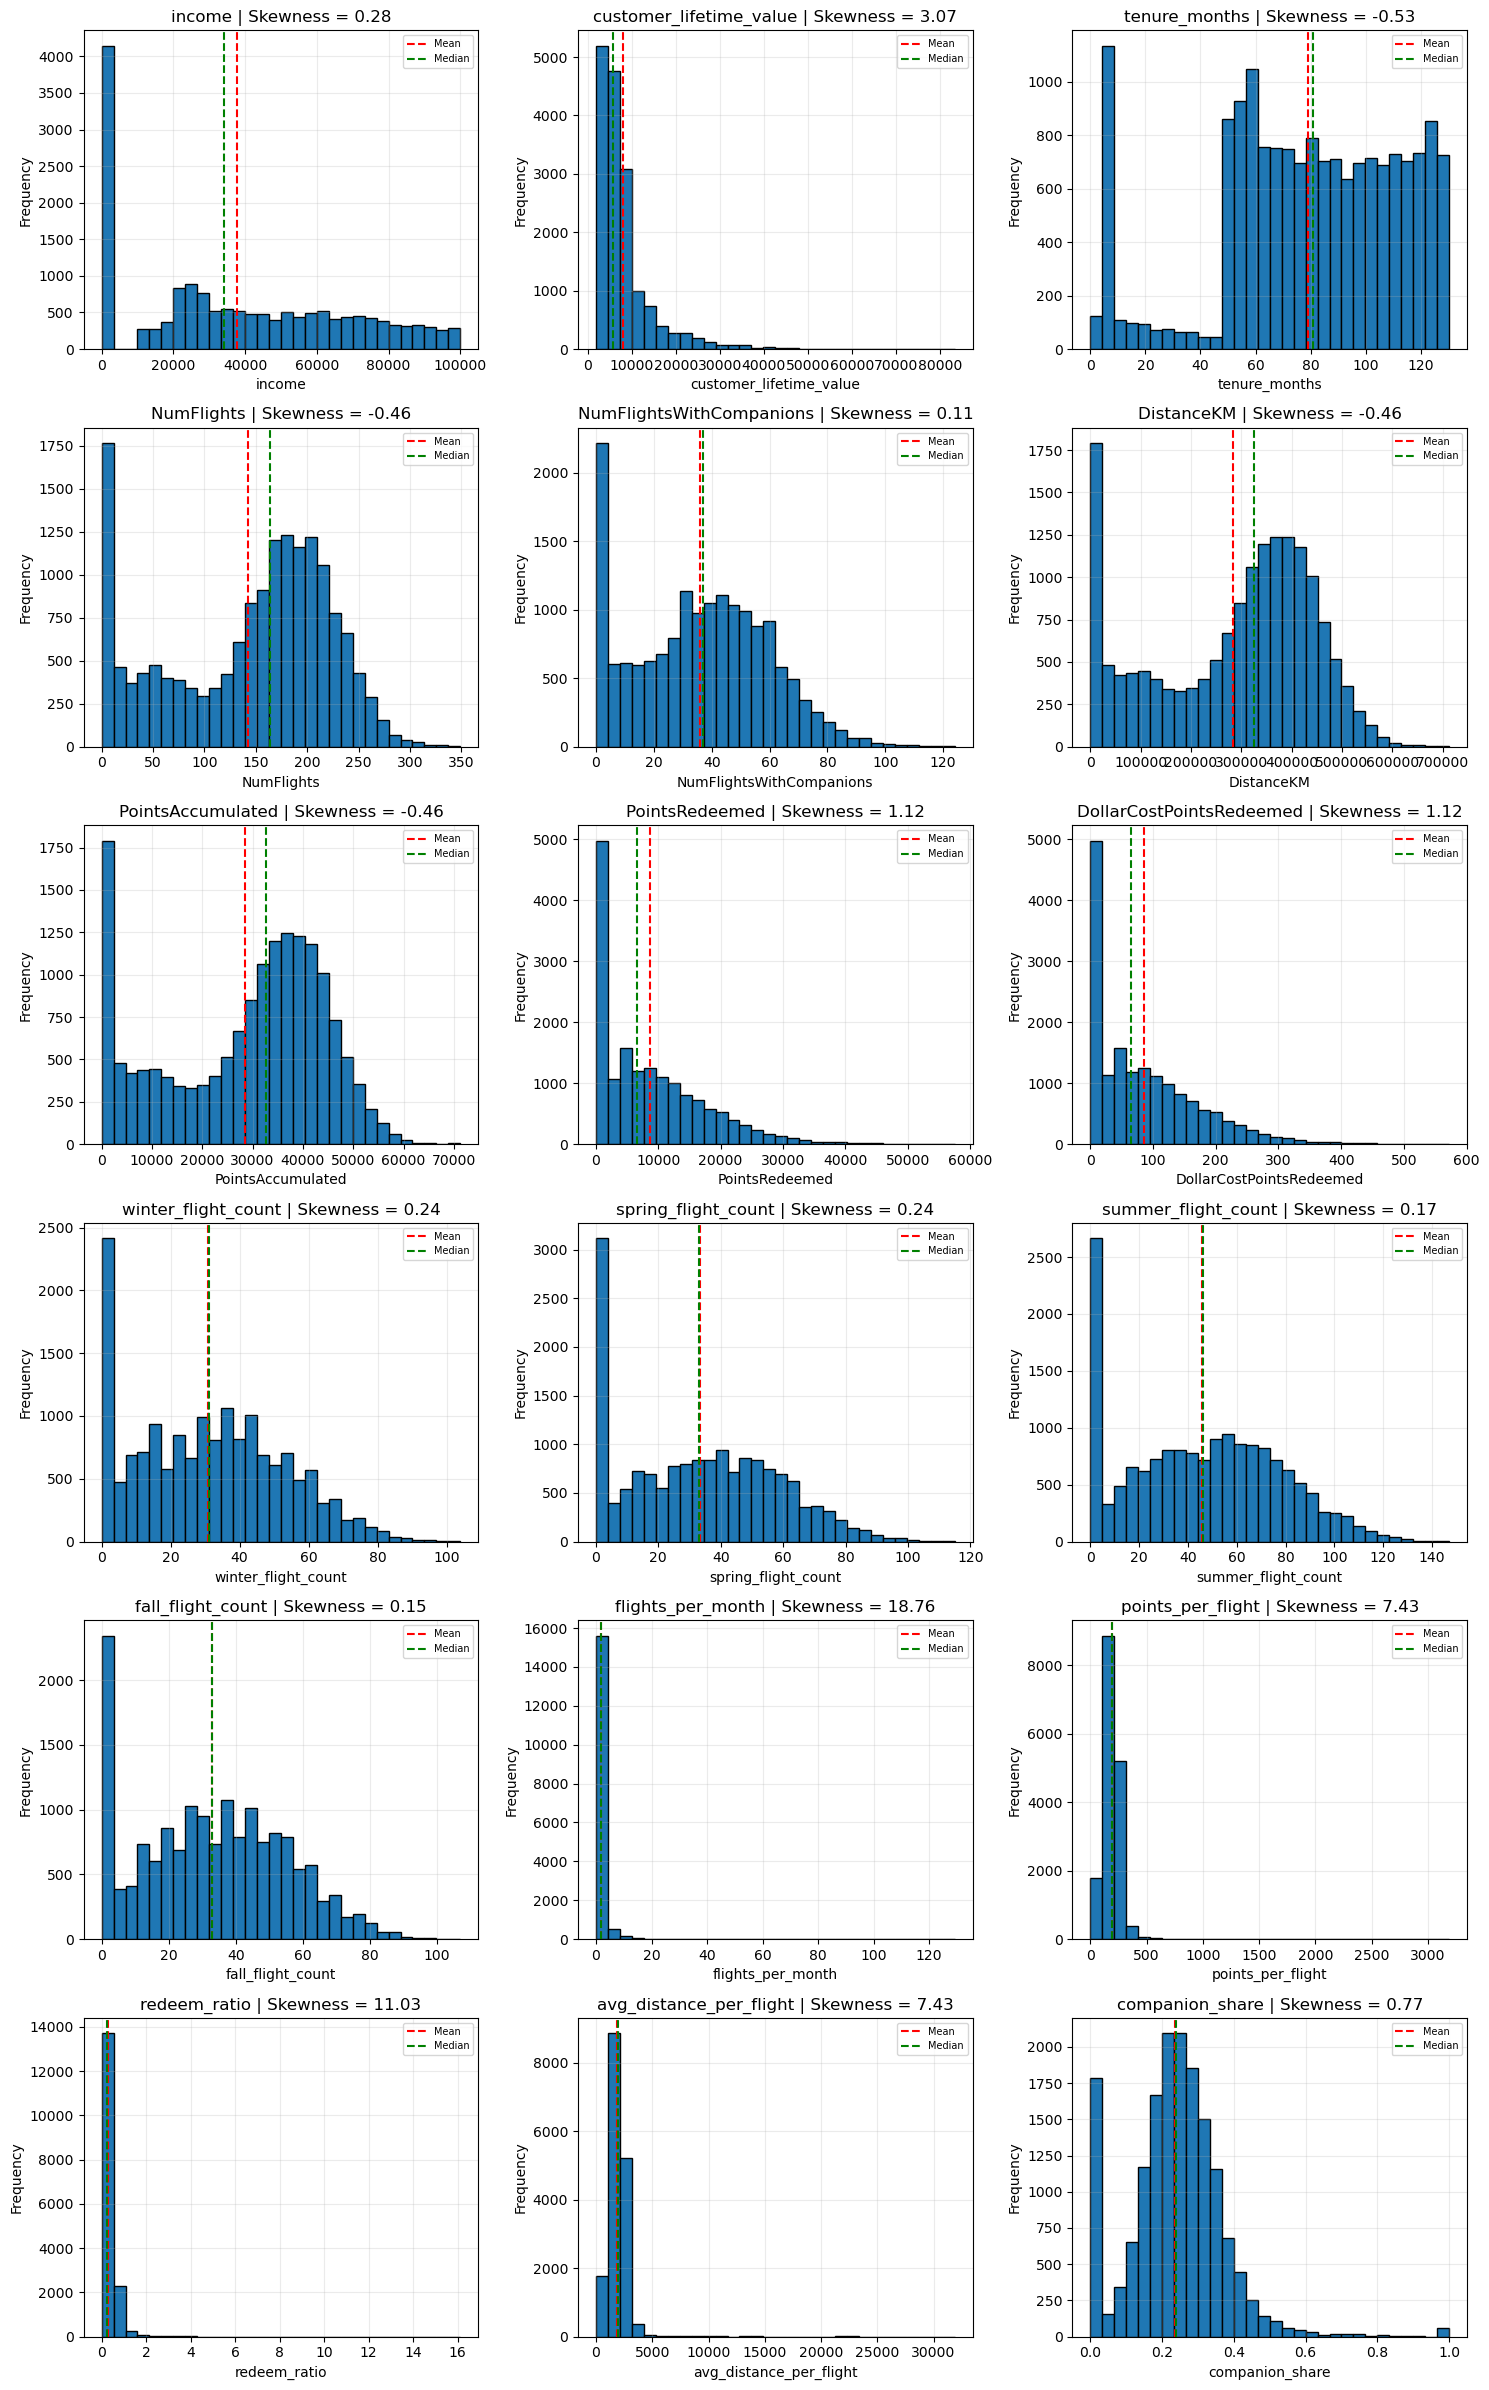

In [15]:
def plot_skewness_grid(df, cols, bins=30, figsize=(15, 4)):

    n = len(cols)
    if n == 0:
        return

    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize[0], figsize[1] * nrows)
    )
    axes = np.atleast_1d(axes).ravel()

    for i, c in enumerate(cols):
        ax = axes[i]
        s = df[c].dropna()
        if s.empty:
            ax.set_visible(False)
            continue

        skew = s.skew()

        ax.hist(s, bins=bins, edgecolor="black")
        ax.axvline(s.mean(), color="red", linestyle="--", label="Mean")
        ax.axvline(s.median(), color="green", linestyle="--", label="Median")

        ax.set_title(f"{c} | Skewness = {skew:.2f}")
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.25)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()



plot_skewness_grid(fe_df, numeric_cols)

In [16]:
fe_df.describe()

,Loyalty#,income,customer_lifetime_value,is_cancelled,tenure_months,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,...,is_peak_season_proxy,winter_flight_count,spring_flight_count,summer_flight_count,fall_flight_count,flights_per_month,points_per_flight,redeem_ratio,avg_distance_per_flight,companion_share
count,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,...,16375.0,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000
mean,549432.932641,37721.547359,7982.088433,0.124947,78.890644,142.865527,36.013618,284344.443652,28428.845635,8601.144116,...,0.0,30.935573,33.333802,45.616611,32.979542,1.973221,190.124675,0.291659,1901.642979,0.235229
std,258720.547621,30342.177810,6841.119253,0.330668,33.343340,80.021292,23.298295,159594.566701,15956.795148,8707.423785,...,0.0,21.567236,24.583544,31.626458,21.913014,2.079644,108.708076,0.415980,1087.255919,0.133763
min,100018.000000,0.000000,1898.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326276.000000,0.000000,3979.390000,0.000000,57.800000,75.000000,17.000000,150940.300000,15090.480000,0.000000,...,0.0,13.000000,12.000000,19.000000,16.000000,1.219614,160.239253,0.000000,1602.668211,0.165854
50%,550434.000000,34115.000000,5781.020000,0.000000,80.900000,164.000000,37.000000,326066.000000,32600.040000,6627.000000,...,0.0,31.000000,33.000000,46.000000,33.000000,1.786260,193.726940,0.221774,1937.571101,0.238411
75%,771330.000000,62375.000000,8936.970000,0.000000,106.300000,204.000000,53.000000,406698.450000,40662.755000,13663.850000,...,0.0,47.000000,52.000000,69.000000,49.000000,2.340101,228.041211,0.428180,2280.893431,0.308669
max,999986.000000,99981.000000,83325.380000,1.000000,130.300000,349.000000,124.000000,712729.600000,71264.460000,57527.800000,...,0.0,104.000000,115.000000,147.000000,107.000000,129.166667,3187.000000,16.125899,31875.000000,1.000000


In [17]:
fe_df['clv_band'] = pd.cut(
    fe_df['customer_lifetime_value'].fillna(0),
    bins=[-1, 5000, 15000, 30000, np.inf],
    labels=['low_value', 'mid_value', 'high_value', 'very_high_value']
)

fe_df['points_redeemed_band'] = pd.cut(
    fe_df['PointsRedeemed'].fillna(0),
    bins=[-1, 0, 1000, 5000, np.inf],
    labels=['none', 'low', 'medium', 'high']
)

fe_df['num_flights_band'] = pd.cut(
    fe_df['NumFlights'].fillna(0),
    bins=[-1, 0, 3, 8, np.inf],
    labels=['no_travel', 'occasional', 'regular', 'frequent']
)

fe_df['companion_flights_band'] = pd.cut(
    fe_df['NumFlightsWithCompanions'].fillna(0),
    bins=[-1, 0, 2, 6, np.inf],
    labels=['solo_only', 'occasional_companion', 'family_traveler', 'group_traveler']
)

fe_df['avg_distance_per_flight'] = np.where(
    fe_df['NumFlights'] > 0,
    fe_df['DistanceKM'] / fe_df['NumFlights'],
    0
)

fe_df['avg_distance_per_flight_band'] = pd.cut(
    fe_df['avg_distance_per_flight'],
    bins=[-1, 0, 1500, 3500, np.inf],
    labels=['no_flights', 'short_haul_traveler', 'medium_haul_traveler', 'long_haul_traveler']
)

fe_df['redeem_ratio'] = np.where(
    fe_df['PointsAccumulated'] > 0,
    fe_df['PointsRedeemed'] / fe_df['PointsAccumulated'],
    0
)

fe_df['redeem_ratio_band'] = pd.cut(
    fe_df['redeem_ratio'],
    bins=[-1, 0, 0.1, 0.4, 0.8, np.inf],
    labels=['no_points', 'rare_redeemer', 'light_redeemer', 'active_redeemer', 'heavy_redeemer']
)

fe_df['tenure_band'] = pd.cut(
    fe_df['tenure_months'].fillna(0),
    bins=[-1, 12, 36, 72, np.inf],
    labels=['new_customer', 'established', 'loyal', 'veteran']
)

fe_df['income_band'] = pd.cut(
    fe_df['income'].fillna(0),
    bins=[-1, 30000, 60000, 100000, np.inf],
    labels=['low_income', 'mid_income', 'upper_mid_income', 'high_income']
)
fe_df.isna().sum()[
    fe_df.isna().sum() > 0
].sort_values(ascending=False)

Series([], dtype: int64)

In [18]:
fe_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16375 entries, 0 to 16374
Data columns (total 79 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Loyalty#                      16375 non-null  int64   
 1   customer_name                 16375 non-null  object  
 2   province                      16375 non-null  object  
 3   city                          16375 non-null  object  
 4   postal_code                   16375 non-null  object  
 5   gender                        16375 non-null  object  
 6   education                     16375 non-null  object  
 7   location_code                 16375 non-null  object  
 8   income                        16375 non-null  float64 
 9   marital_status                16375 non-null  object  
 10  loyalty_status                16375 non-null  object  
 11  enrollment_date               16375 non-null  object  
 12  enrollment_type               16375 non-null  

# OUTLIERS (IQR):

In [19]:
def boxplot_grid(df, cols, ncols=3, figsize=(14, 8), showfliers=True):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col].astype(float)
        ax.boxplot(s.dropna().values, vert=True, showmeans=False, showfliers=showfliers)
        ax.set_title(f"Boxplot of {col}")
        ax.set_xticks([])                 
        ax.set_ylabel(col)
        ax.grid(axis="y", alpha=0.25)

    # Hide unused subplot:
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

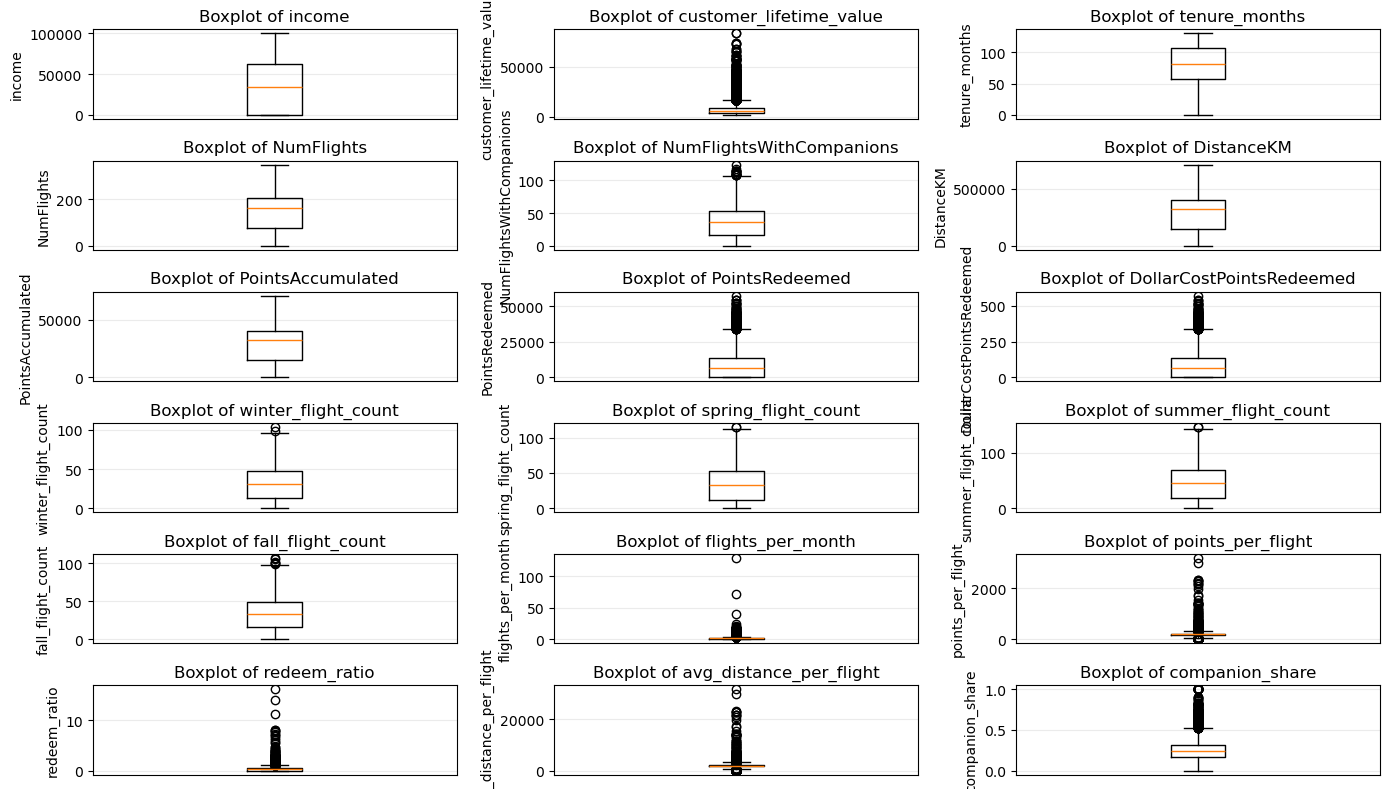

In [20]:
boxplot_grid(fe_df, numeric_cols, ncols=3, figsize=(14, 8), showfliers=True)

In [21]:
def iqr_outlier_summary(df: pd.DataFrame, cols, k: float = 1.5):

    rows = []
    masks = {}

    n = len(df)

    for col in cols:
        s = df[col].dropna()

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - k * iqr
        upper = q3 + k * iqr

        mask = (df[col] < lower) | (df[col] > upper)
        n_out = mask.sum()
        pct_out = n_out / n * 100

        masks[col] = mask

        rows.append({
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "n_outliers": n_out,
            "pct_outliers": pct_out
        })

    summary_df = pd.DataFrame(rows)

    print("-" * 70)
    print("IQR outlier summary")
    print("-" * 70)
    for _, r in summary_df.iterrows():
        print(f"Feature        : {r['feature']}")
        print(f"  Q1           : {r['Q1']:.3f}")
        print(f"  Q3           : {r['Q3']:.3f}")
        print(f"  IQR          : {r['IQR']:.3f}")
        print(f"  Lower bound  : {r['lower_bound']:.3f}")
        print(f"  Upper bound  : {r['upper_bound']:.3f}")
        print(f"  Outliers     : {int(r['n_outliers'])} "
              f"({r['pct_outliers']:.2f}% of rows)")
        print("-" * 70)

    return summary_df, masks


In [22]:
iqr_summary, iqr_masks = iqr_outlier_summary(fe_df, numeric_cols)

----------------------------------------------------------------------
IQR outlier summary
----------------------------------------------------------------------
Feature        : income
  Q1           : 0.000
  Q3           : 62375.000
  IQR          : 62375.000
  Lower bound  : -93562.500
  Upper bound  : 155937.500
  Outliers     : 0 (0.00% of rows)
----------------------------------------------------------------------
Feature        : customer_lifetime_value
  Q1           : 3979.390
  Q3           : 8936.970
  IQR          : 4957.580
  Lower bound  : -3456.980
  Upper bound  : 16373.340
  Outliers     : 1447 (8.84% of rows)
----------------------------------------------------------------------
Feature        : tenure_months
  Q1           : 57.800
  Q3           : 106.300
  IQR          : 48.500
  Lower bound  : -14.950
  Upper bound  : 179.050
  Outliers     : 0 (0.00% of rows)
----------------------------------------------------------------------
Feature        : NumFlights
  Q1 

In [23]:
manual_cols = [
    "tenure_months",
    "points_per_flight",
    "avg_distance_per_flight",
    "customer_lifetime_value",
]

qs = [0.99, 0.995, 0.999]  

rows = []
n = len(fe_df)

for col in manual_cols:
    s = fe_df[col].dropna()

    for q in qs:
        thr = float(s.quantile(q))
        removed_pct = 100 * (fe_df[col] > thr).mean()  
        rows.append({
            "feature": col,
            "quantile": q,
            "suggested_thr": thr,
            "pct_above_thr": removed_pct
        })

suggest_df = pd.DataFrame(rows).sort_values(["feature", "quantile"])
display(suggest_df)


,feature,quantile,suggested_thr,pct_above_thr
6,avg_distance_per_flight,0.990,4139.480733,1.001527
7,avg_distance_per_flight,0.995,5435.803333,0.500763
8,avg_distance_per_flight,0.999,14138.018700,0.103817
9,customer_lifetime_value,0.990,35872.633400,1.001527
10,customer_lifetime_value,0.995,41787.900000,0.458015
11,customer_lifetime_value,0.999,59882.126060,0.103817
3,points_per_flight,0.990,413.887545,1.001527
4,points_per_flight,0.995,543.558667,0.500763
5,points_per_flight,0.999,1413.639670,0.103817
0,tenure_months,0.990,128.800000,0.928244


In [24]:
q = 0.999
manual_quantile_cols = [
    "points_per_flight",
    "avg_distance_per_flight",
    "customer_lifetime_value",
]

manual_thresholds = {
    col: float(fe_df[col].dropna().quantile(q))
    for col in manual_quantile_cols
}

base_index = customers_db.index

per_feature_flags = {}
rows = []

for col, iqr_mask in iqr_masks.items():
    iqr_mask = iqr_mask.reindex(base_index, fill_value=False)

    if col in fe_df.columns:
        x = fe_df[col].reindex(base_index)
    else:
        x = None

    if col in manual_thresholds:
        thr = manual_thresholds[col]
        manual_mask = (x > thr)
        flag = iqr_mask & manual_mask
        rule = f"IQR & manual(q={q})"

    elif col == "total_active_months":
        tam = fe_df["total_active_months"].reindex(base_index)
        ten = fe_df["tenure_months"].reindex(base_index)
        manual_mask = (tam > ten)
        flag = iqr_mask & manual_mask
        rule = "IQR & manual(tam > tenure)"

    else:
        flag = iqr_mask
        rule = "IQR"

    per_feature_flags[col] = flag

    n = int(flag.sum())
    pct = 100 * n / len(base_index)

    rows.append({
        "feature": col,
        "rule": rule,
        "n_removed_by_feature": n,
        "pct_removed_by_feature": pct
    })

summary_df = pd.DataFrame(rows).sort_values("pct_removed_by_feature", ascending=False)

out_remove_total = pd.Series(False, index=base_index)
for flag in per_feature_flags.values():
    out_remove_total |= flag

total_n = int(out_remove_total.sum())
total_pct = 100 * total_n / len(base_index)

print(f"TOTAL to remove: {total_n} / {len(base_index)}  ({total_pct:.2f}%)")
print("\nTop features by % removed:")
display(summary_df.head(20))

print("\nManual thresholds (q=0.999):")
for k, v in manual_thresholds.items():
    print(f"  {k}: {v}")

TOTAL to remove: 1575 / 16375  (9.62%)

Top features by % removed:


,feature,rule,n_removed_by_feature,pct_removed_by_feature
13,flights_per_month,IQR,853,5.209160
15,redeem_ratio,IQR,383,2.338931
17,companion_share,IQR,295,1.801527
8,DollarCostPointsRedeemed,IQR,182,1.111450
7,PointsRedeemed,IQR,178,1.087023
16,avg_distance_per_flight,IQR & manual(q=0.999),17,0.103817
14,points_per_flight,IQR & manual(q=0.999),17,0.103817
1,customer_lifetime_value,IQR & manual(q=0.999),17,0.103817
4,NumFlightsWithCompanions,IQR,16,0.097710
12,fall_flight_count,IQR,6,0.036641



Manual thresholds (q=0.999):
  points_per_flight: 1413.639670000036
  avg_distance_per_flight: 14138.018700000353
  customer_lifetime_value: 59882.12606000365


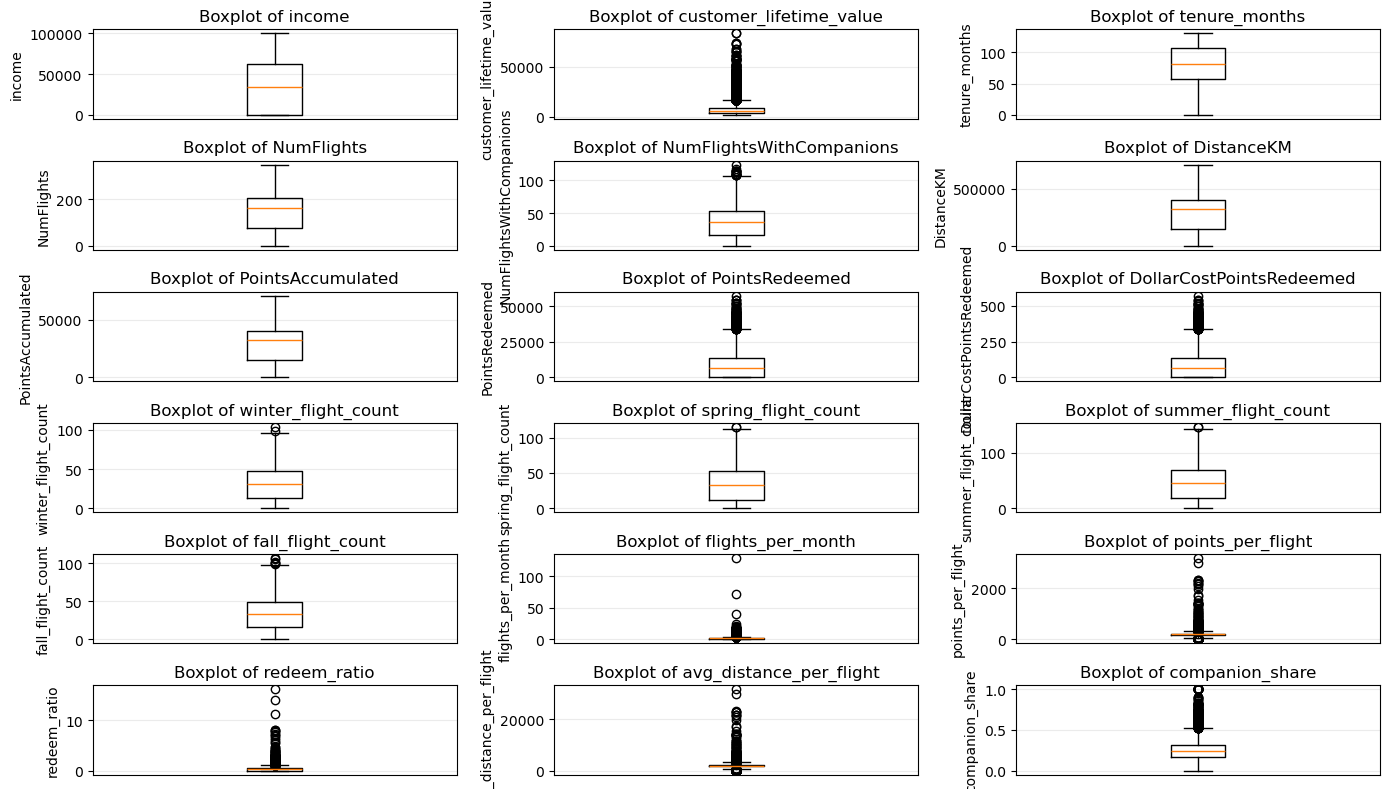

In [25]:
boxplot_grid(fe_df, numeric_cols, ncols=3, figsize=(14, 8), showfliers=True)

We identified potential outliers using a two-step strategy combining an univariate IQR rule and targeted manual filters. First, for each numeric feature we computed IQR-based bounds (Q1 − 1.5·IQR, Q3 + 1.5·IQR) and flagged observations falling outside these limits. For a small set of highly skewed, business-critical variables (e.g., points_per_flight, avg_distance_per_flight, and customer_lifetime_value), we additionally applied manual upper thresholds defined at the 99.9th percentile, and removed records only when both the IQR criterion and the corresponding manual threshold were triggered. Finally, we enforced a consistency rule by flagging and removing cases where total_active_months exceeded tenure_months, since active months cannot logically surpass the total observed membership duration.

In total we removed ~5% of the total data.

## 4. Feature Encoding

After completing feature engineering and discretization, encoding was applied to transform categorical variables into numerical representations. All encoding in this section is performed on a **single dataset (`fe_df`)**, producing an encoded dataset (`fe_df_encoded`) without changing row cardinality.

Encoding choices were driven by **cardinality and semantic meaning** of the features to ensure compatibility with clustering while preserving interpretability.

---

### Dataset Structure at This Stage

At this point in the pipeline:

- **`fe_df`** represents a customer-level dataset with one row per customer
- It contains demographic, temporal, behavioral, and discretized (binned) features
- No further aggregation or merging is performed in this step

The output of this stage is:

- **`fe_df_encoded`**, which retains the same customer-level structure with encoded categorical features

---

### Encoding Strategy Overview

Two encoding strategies are applied based on feature characteristics:

- **One-hot encoding** for low-cardinality nominal categorical features
- **Ordinal encoding** for discretized (binned) features with an inherent order

This hybrid approach balances numerical suitability for clustering with interpretability and behavioral meaning.

---

### One-Hot Encoding of Low-Cardinality Nominal Features

#### Encoded Features

One-hot encoding was applied only to categorical columns with **very few unique string values**:

- `gender`  
- `education`  
- `location_code`  
- `marital_status`  
- `loyalty_status`  
- `season`  

These features represent independent categories and do not have a natural order.

#### Why One-Hot Encoding Was Used

- These columns have **low cardinality**, keeping dimensionality manageable
- One-hot encoding avoids imposing artificial ordinal relationships
- Each category contributes independently to distance-based similarity
- All categories were retained (`drop_first=False`) to preserve interpretability  
- Multicollinearity is not a concern, as the dataset is intended for clustering rather than regression

---

### Ordinal Encoding of Discretized (Binned) Features

#### Encoded Features

All discretized features created during the binning stage were encoded using ordinal encoding:

- `clv_band`  
- `points_redeemed_band`  
- `num_flights_band`  
- `companion_flights_band`  
- `avg_distance_per_flight_band`  
- `redeem_ratio_band`  
- `tenure_band`  
- `income_band`  

---

### Choice of Ordinal Encoding

#### Why Ordinal Encoding Was Used

- These features have a **clear and meaningful order**
- Ordinal encoding preserves relative magnitude between categories
- It allows clustering algorithms to recognize progression and intensity rather than treating categories as unrelated

Examples of preserved ordering include:
- low_value < mid_value < high_value < very_high_value  
- no_travel < occasional < regular < frequent  
- new_customer < established < loyal < veteran  

#### Controlled Category Ordering

Each ordinal feature was encoded using a **predefined category order**, ensuring:
- Semantic correctness
- Consistent numerical mappings
- Reproducibility across runs

---

### Resulting Encoded Dataset

The final output, `fe_df_encoded`:
- Maintains one row per customer
- Includes one-hot encoded low-cardinality categorical features
- Includes ordinal-encoded behavioral and value-based bands
- Is fully numerical and suitable for clustering and distance-based analysis

---

### Summary

Feature encoding was applied using a principled, feature-aware strategy. Low-cardinality nominal features were one-hot encoded to preserve category independence, while discretized behavioral features were ordinally encoded to retain meaningful order. This approach ensures numerical readiness for clustering while maintaining interpretability and minimizing unnecessary dimensional expansion.


In [26]:
fe_df_encoded = fe_df.copy()

fe_categorical_cols = [
    'gender',
    'education',
    'location_code',
    'marital_status',
    'loyalty_status',
    'season',
]

fe_df_encoded = pd.get_dummies(
    fe_df_encoded,
    columns=fe_categorical_cols,
    drop_first=False
)


In [27]:
ordinal_columns = [
    'clv_band',
    'points_redeemed_band',
    'num_flights_band',
    'companion_flights_band',
    'avg_distance_per_flight_band',
    'redeem_ratio_band',
    'tenure_band',
    'income_band'
]

ordinal_categories = [
    ['low_value', 'mid_value', 'high_value', 'very_high_value'],
    ['none', 'low', 'medium', 'high'],
    ['no_travel', 'occasional', 'regular', 'frequent'],
    ['solo_only', 'occasional_companion', 'family_traveler', 'group_traveler'],
    ['no_flights', 'short_haul_traveler', 'medium_haul_traveler', 'long_haul_traveler'],
    ['no_points', 'rare_redeemer', 'light_redeemer', 'active_redeemer', 'heavy_redeemer'],
    ['new_customer', 'established', 'loyal', 'veteran'],
    ['low_income', 'mid_income', 'upper_mid_income', 'high_income']
]
fe_df_encoded = fe_df_encoded.copy()

ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)

fe_df_encoded[ordinal_columns] = ordinal_encoder.fit_transform(
    fe_df_encoded[ordinal_columns]
)


In [28]:
fe_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16375 entries, 0 to 16374
Data columns (total 93 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Loyalty#                        16375 non-null  int64  
 1   customer_name                   16375 non-null  object 
 2   province                        16375 non-null  object 
 3   city                            16375 non-null  object 
 4   postal_code                     16375 non-null  object 
 5   income                          16375 non-null  float64
 6   enrollment_date                 16375 non-null  object 
 7   enrollment_type                 16375 non-null  object 
 8   customer_lifetime_value         16375 non-null  float64
 9   is_cancelled                    16375 non-null  int64  
 10  tenure_months                   16375 non-null  float64
 11  NumFlights                      16375 non-null  int64  
 12  NumFlightsWithCompanions        

## 6. Log Transformation of Skewed Features

Before applying feature scaling, numerical variables were examined for skewness to identify distributions that could negatively affect distance-based clustering. This step focuses on reducing distributional imbalance caused by extreme values while preserving the interpretability of customer behavior.

---

### Why Log Transformation Was Necessary

Several customer-level numerical features in the dataset represent accumulated quantities or long-tailed measures, such as flight counts, monetary values, travel distance, and loyalty points. These types of features often exhibit **right-skewed distributions**, where a small subset of customers holds disproportionately large values.

If left uncorrected, such skewness can dominate distance calculations and reduce the ability of clustering algorithms to identify meaningful structure among the majority of customers.

---

### Skewness Assessment

Skewness was systematically assessed for a predefined set of candidate numerical features, including:
- Flight volume and companion travel counts
- Distance and monetary redemption metrics
- Loyalty value, tenure, and income-related attributes

The assessment combined:
- **Absolute statistical skewness values**, used to rank features by severity
- **Histogram visualizations**, used to inspect distribution shape, spread, and the presence of extreme values

This dual approach allowed both quantitative and visual identification of highly skewed variables.

---

### Selection of Log Transformation Candidates

Based on the skewness ranking and histogram inspection, the following features were selected for log transformation:
- **Customer Lifetime Value**
- **Average Distance per Flight**
- **Points Redeemed**

These features exhibited strong right skew and long-tailed distributions that could not be sufficiently corrected through discretization alone.

Other numerical features were reviewed but not transformed when:
- Skewness was comparatively lower
- The feature had already been discretized into categorical bands
- The variable represented bounded or ratio-based behavior
- Log transformation would reduce interpretability without clear benefit

---

### Application of Log Transformation

Log transformation was applied using a `log1p` function, ensuring numerical stability and safe handling of zero-valued observations. This transformation compresses extreme values while preserving relative differences among lower and mid-range observations.

---

### Effect of Log Transformation

After transformation, the selected features showed substantially reduced skewness and more symmetric distributions. Histogram comparisons before and after transformation confirmed:
- Reduced influence of extreme outliers
- Improved distribution balance
- Better suitability for subsequent scaling and clustering

---

### Why Log Transformation Was Applied Selectively

Log transformation was not applied uniformly across all numerical features.

**Reasons for selective application include:**
- Avoiding unnecessary distortion of already stable distributions
- Preserving interpretability of behavioral ratios and binned features
- Preventing over-normalization that could obscure meaningful customer differences

This selective approach ensures an effective balance between normalization and behavioral fidelity, improving clustering performance without sacrificing interpretability.

---

### Summary

Log transformation was applied selectively to a small set of highly skewed numerical features identified through statistical and visual analysis. By reducing the impact of extreme values while preserving meaningful variation, this step improves the stability and effectiveness of downstream scaling and clustering.


In [29]:
log_candidate_cols = [
    'NumFlights',
    'NumFlightsWithCompanions',
    'DistanceKM',
    'PointsAccumulated',
    'PointsRedeemed',
    'DollarCostPointsRedeemed',
    'customer_lifetime_value',
    'avg_distance_per_flight',
    'tenure_months',
    'income',
]

In [30]:
skew_check = (
    fe_df_encoded[log_candidate_cols]
    .skew()
    .abs()
    .sort_values(ascending=False)
)

skew_check

avg_distance_per_flight     7.433701
customer_lifetime_value     3.073379
DollarCostPointsRedeemed    1.122406
PointsRedeemed              1.120092
tenure_months               0.534645
DistanceKM                  0.461043
PointsAccumulated           0.460948
NumFlights                  0.457592
income                      0.278627
NumFlightsWithCompanions    0.106967
dtype: float64

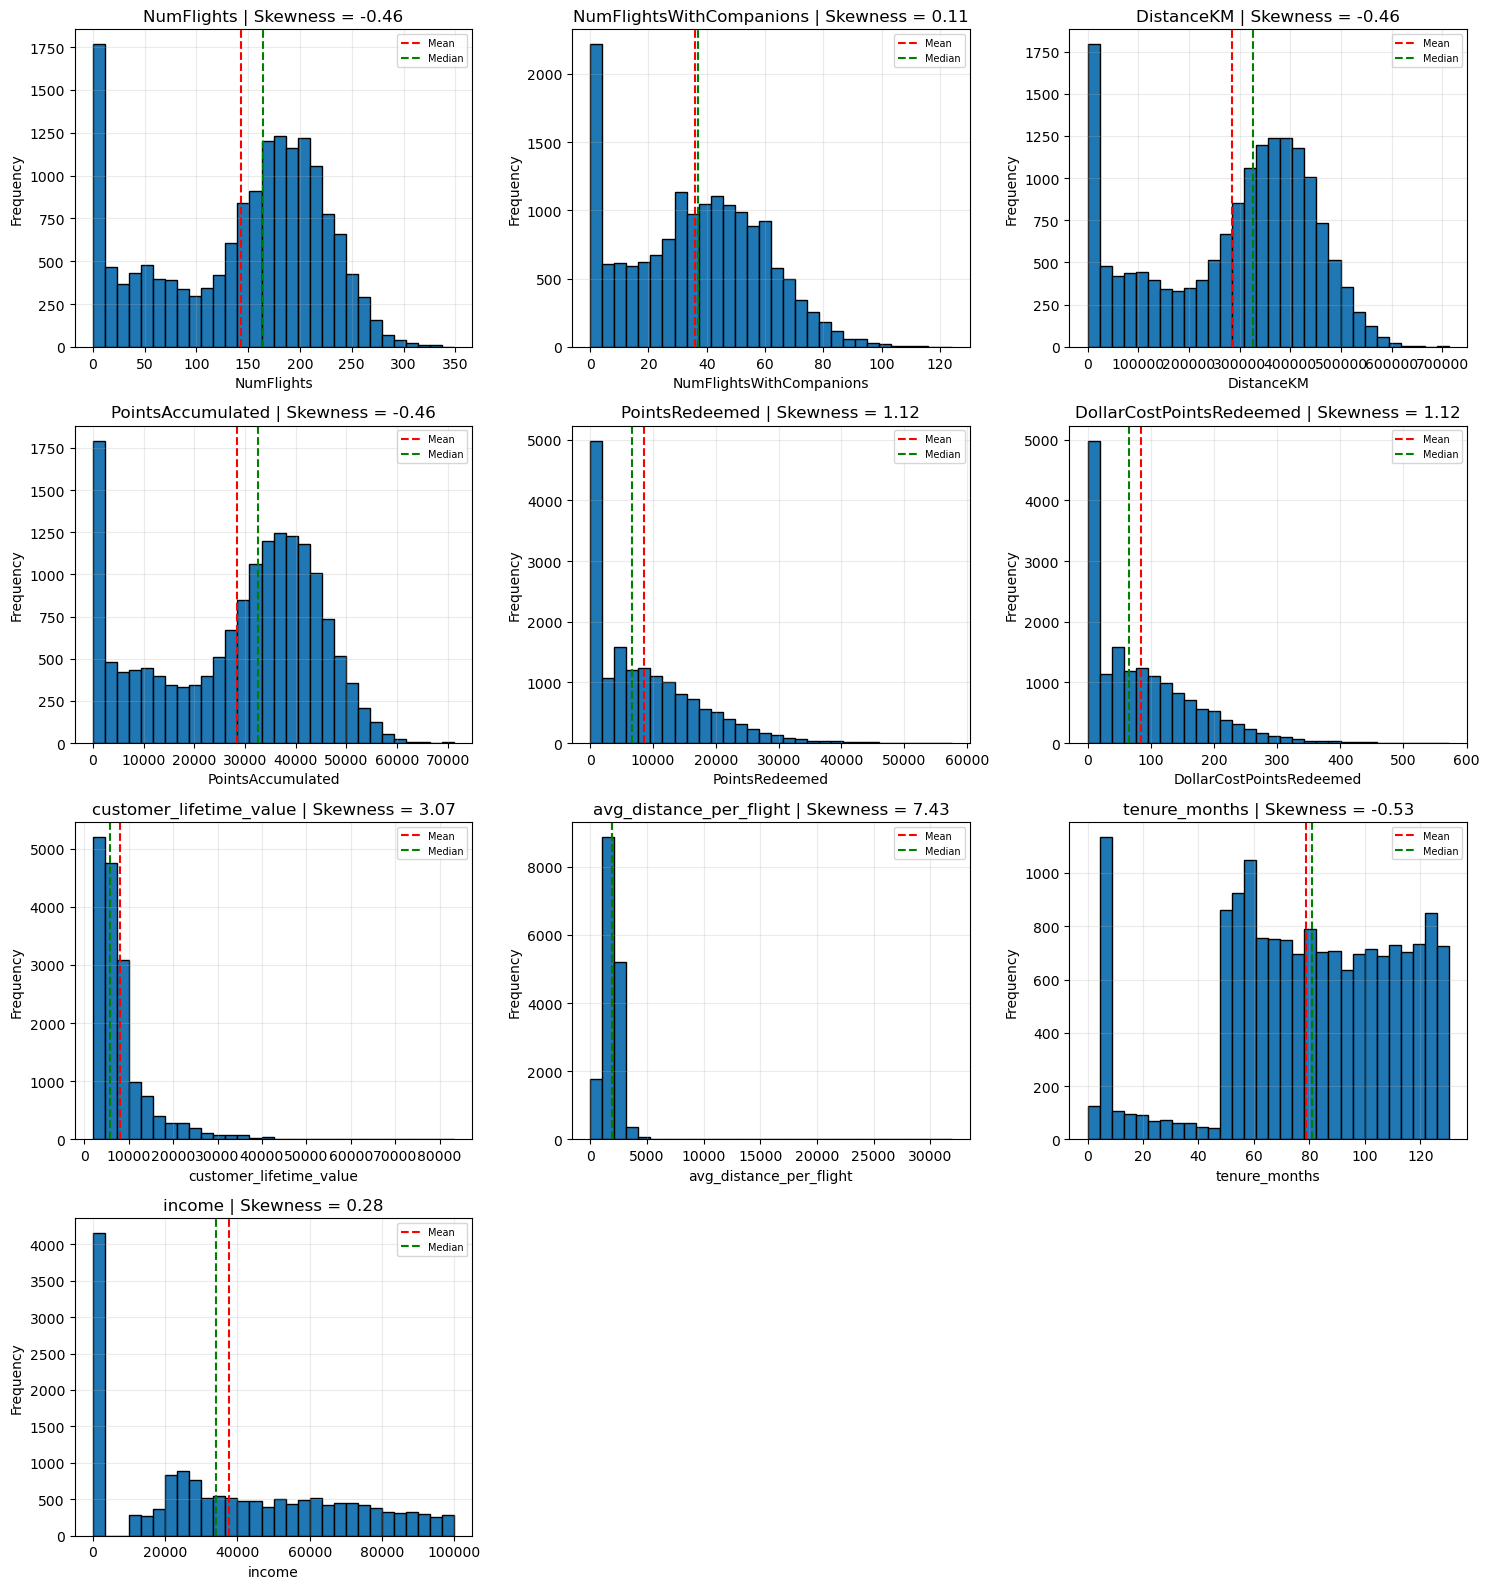

In [31]:
plot_skewness_grid(fe_df_encoded, log_candidate_cols)

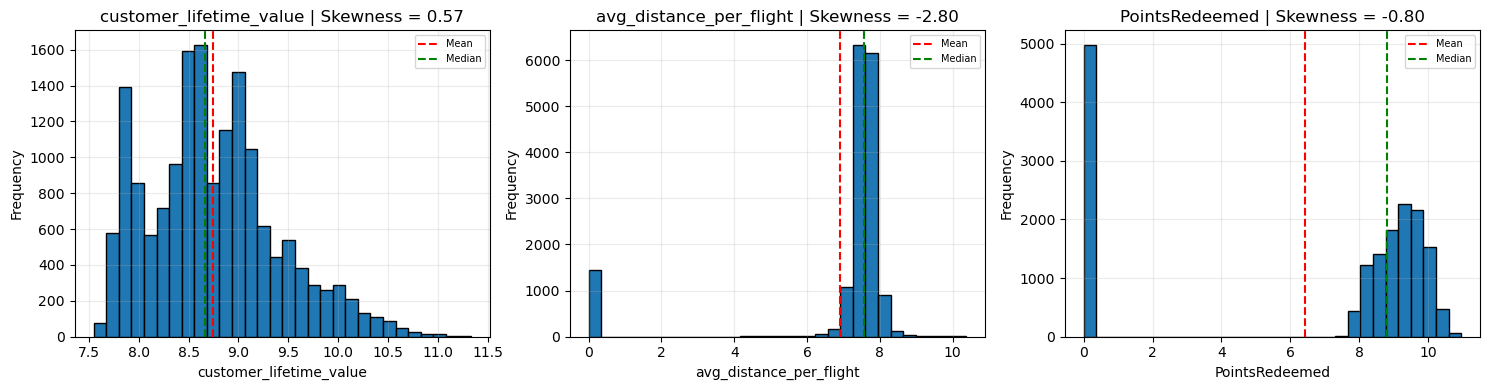

In [32]:
log_transformed_cols = ['customer_lifetime_value', 'avg_distance_per_flight', 'PointsRedeemed']
fe_df_log = fe_df_encoded.copy()

for col in log_transformed_cols:
    fe_df_log[col] = np.log1p(fe_df_log[col])

plot_skewness_grid(fe_df_log, log_transformed_cols)

## 7. Feature Scaling and Normalization

After addressing skewness through log transformation, numerical features were scaled to ensure equal contribution during distance-based clustering.

---

### Why Feature Scaling Is Required

The dataset contains numerical features with very different units and ranges, including:
- Counts (e.g., number of flights)
- Distances (kilometers)
- Monetary values
- Ratios and averages

Without scaling, features with larger numeric ranges would disproportionately influence similarity calculations.

---

### Scaling Strategy for Customer-Level Data

For the customer-level dataset, numerical features representing behavioral intensity, monetary value, and engagement were scaled.

**Why these features were scaled**
- They vary significantly in magnitude
- They are directly used in clustering
- Equal weighting across features is required for fair distance computation

Standardization ensures that each feature contributes proportionately.

---

### Scaling Strategy for Flight-Level Data

Numerical features in the flight-level dataset were also scaled to support consistent analysis and potential reuse for modeling or exploration.

Categorical and geographic features were excluded from scaling to preserve their original meaning and structure.

---

### Scaling Method Used

Standardization (z-score normalization) was applied.

**Why standardization was chosen**
- Centers features around zero
- Scales to unit variance
- Works well with distance-based clustering algorithms

---


In [33]:
fe_df_scaled = fe_df_log.copy()

scaler_fe = StandardScaler()

to_be_scaled_columns = numeric_cols + ordinal_columns

fe_df_scaled[to_be_scaled_columns] = scaler_fe.fit_transform(
    fe_df_scaled[to_be_scaled_columns]
)

In [34]:
fe_df_scaled.isna().sum()[fe_df_scaled.isna().sum() > 0].sort_values(ascending=True)

Series([], dtype: int64)